# Wind Generation in AIB Countries

This notebook quantifies wind power generation across AIB (Association of Issuing Bodies) member countries using ENTSO-E actual generation data, and compares it to Guarantee of Origin (GO) issuance volumes.

In [96]:
aib_members = [
    'AL', 'AT', 'BE', 'BA', 'BG', 'HR', 'CY', 'CZ', 'DK', 'EE',
    'FI', 'FR', 'GE', 'DE', 'GR', 'HU', 'IS', 'IE', 'IT', 'XK', 
    'LV', 'LT', 'LU', 'ME', 'NL', 'MK', 'NO', 'PT', 'RO', 'RS', 
    'SK', 'SI', 'ES', 'SE', 'CH', 'UA'
]

aib_electricity_scheme_group = [
    'AT', 'BE', 'HR', 'CY', 'CZ', 'DK', 'EE', 'FI', 'FR', 'DE', 
    'GR', 'HU', 'IS', 'IE', 'IT', 'LV', 'LT', 'LU', 'NL', 'NO', 
    'PT', 'RS', 'SK', 'SI', 'ES', 'SE', 'CH'
]

country_to_grid = {'AT': 'APG', 'BE': 'ELIA', 'FR': 'RTE', 'GB': 'NGRID', 'NL': 'TENNET'}
grid_to_country = {v: k for k, v in country_to_grid.items()}

## Data Collection

We query the ENTSO-E wind production curves from the database. Each curve represents actual wind generation (MW) for a specific country/zone and type (onshore/offshore). The data is resampled to hourly granularity where needed, deduplicated by keeping the latest forecast revision, and aggregated per country.

In [ ]:
from kad_functions.sql_data import get_sql_query

wind_query = """
SELECT CurveId, CurveName, CountryCode
FROM pub.dimMetadata
WHERE (CurveName LIKE '%ENTSOE-POWER-PRODUCTION%wind%'
    OR CurveName LIKE '%EntsoE-ActualGeneration%wind%'
    OR CurveName LIKE '%EntsoE_Actual_Generation%wind%'
    OR CurveName LIKE '%EntsoE_ActualGeneration%wind%')
    AND Curvename NOT LIKE '%raw'
ORDER BY CountryCode
"""

wind_countries = get_sql_query(wind_query)
wind_countries = wind_countries.sort_values(by='CountryCode').reset_index(drop=True)

wind_countries.loc[wind_countries['CurveName'].str.contains('-APG-', case=False, na=False), 'CountryCode'] = 'AT'
wind_countries.loc[wind_countries['CurveName'].str.contains('-NO', case=False, na=False), 'CountryCode'] = 'NO'
wind_countries.loc[wind_countries['CurveName'].str.contains('-IT-NORTH', case=False, na=False), 'CountryCode'] = 'IT'

wind_countries = wind_countries[wind_countries['CountryCode'].isin(aib_electricity_scheme_group)]
wind_countries = wind_countries.sort_values(by='CountryCode').reset_index(drop=True)

display(wind_countries)

,CurveId,CurveName,CountryCode
0,910000136,EntsoE_ActualGeneration_AT_WindOnshore_PROD,AT
1,910000137,EntsoE_ActualGeneration_AT_WindOnshore_CONS,AT
2,1000318275,ENTSOE-POWER-PRODUCTION-ACTUAL-APG-WIND-ONSHOR...,AT
3,1000318277,ENTSOE-POWER-PRODUCTION-ACTUAL-ELIA-WIND-ONSHO...,BE
4,1000318285,ENTSOE-POWER-PRODUCTION-ACTUAL-ELIA-WIND-OFFSH...,BE
...,...,...,...
113,1500019441,ENTSOE_ACTUAL_GENERATION_ONSHORE_WIND_MW_HOURL...,SE
114,1500019440,ENTSOE_ACTUAL_GENERATION_ONSHORE_WIND_MW_HOURL...,SE
115,1500026362,ENTSOE-POWER-PRODUCTION-ACTUAL-SE2-WIND-ONSHOR...,SE
116,910003062,ENTSOE_ActualGeneration_SI_WIND-ONSHORE__PROD,SI


In [98]:
# Country filters - selected curve IDs to avoid double-counting
# Strategy: use one consistent source per country, prefer ACTUAL/national-level curves,
# only PROD (not CONS), sum regional curves for IT/NO/DK
filtered_curve_ids = [
    '1000318275', '1000318283',  # AT onshore, offshore (APG)
    '1500029398', '1500029397',  # BE onshore, offshore
    '910000231', '1500029461',   # CH onshore, offshore
    '910003006', '1500029493',   # CZ onshore, offshore
    '1000318274', '1000318282',  # DE onshore, offshore (national, not individual TSOs)
    '1000318280', '1000318288',  # DK1 onshore, offshore
    '1000318281', '1000318289',  # DK2 onshore, offshore
    '1500028969', '1500028966',  # EE onshore, offshore
    '910000225', '910000224',    # ES onshore, offshore
    '1500019439', '1500019432',  # FI onshore, offshore
    '1000318278', '1000318286',  # FR onshore, offshore (RTE)
    '910003087',                 # GR onshore only
    '910004527',                 # HR onshore only
    '910003032',                 # HU onshore PROD only (not CONS)
    '910002524',                 # IE onshore only
    # IT regions - onshore PROD
    '910000288', '910000262', '910000273', '910000330',  # IT NORTH, CNOR, CSOUTH, SOUTH onshore
    '910000322', '910000312', '1500023506',              # IT SICILY, SARDINIA, Calabria onshore
    # IT regions - offshore PROD
    '1500023502', '1500023504', '1500023503', '1500023499',  # IT NORTH, CNOR, CSOUTH, SOUTH offshore
    '1500023500', '1500023501', '1500023507',                # IT SICILY, SARDINIA, Calabria offshore
    '1500029109', '1500029108',  # LT onshore, offshore
    '1500029081', '1500029080',  # LV onshore, offshore
    '1000318276', '1000318284',  # NL onshore, offshore (TenneT)
    # NO bidding zones - onshore
    '1500026496', '1500026538', '1500026580', '1500026622', '1500026664',  # NO1-NO5 onshore
    # NO bidding zones - offshore
    '1500026495', '1500026537', '1500026579', '1500026621', '1500026663',  # NO1-NO5 offshore
    '910000344', '1500023370',   # PT onshore, offshore
    '1500029525', '1500029523',  # SE onshore, offshore (national aggregate)
    '910003062',                 # SI onshore only
    '910003020',                 # SK onshore only
]

# Filter wind_countries to only selected curves
wind_countries = wind_countries[wind_countries['CurveId'].astype(str).isin(filtered_curve_ids)].reset_index(drop=True)
print(f"Filtered to {len(wind_countries)} curves across {wind_countries['CountryCode'].nunique()} countries")
display(wind_countries)

Filtered to 62 curves across 23 countries


,CurveId,CurveName,CountryCode
0,1000318275,ENTSOE-POWER-PRODUCTION-ACTUAL-APG-WIND-ONSHOR...,AT
1,1500029397,ENTSOE-POWER-PRODUCTION-ACTUAL-BE-WIND-OFFSHOR...,BE
2,1500029398,ENTSOE-POWER-PRODUCTION-ACTUAL-BE-WIND-ONSHORE-MW,BE
3,910000231,EntsoE-ActualGeneration-CH-WindOnshore,CH
4,1500029461,ENTSOE-POWER-PRODUCTION-ACTUAL-CH-WIND-OFFSHOR...,CH
...,...,...,...
57,1500026579,ENTSOE-POWER-PRODUCTION-ACTUAL-NO3-WIND-OFFSHO...,NO
58,1500029525,ENTSOE_ACTUAL_GENERATION_WIND_ONSHORE_MW_HOURL...,SE
59,1500029523,ENTSOE_ACTUAL_GENERATION_WIND_OFFSHORE_MW_HOUR...,SE
60,910003062,ENTSOE_ActualGeneration_SI_WIND-ONSHORE__PROD,SI


In [99]:
available_wind_countries = sorted(set(wind_countries['CountryCode']))

print("Countries with wind generation data:", available_wind_countries)
print("Number of countries with wind generation data:", len(available_wind_countries))
print("Countries without wind generation data:", sorted(set(aib_electricity_scheme_group) - set(available_wind_countries)))

Countries with wind generation data: ['AT', 'BE', 'CH', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LV', 'NL', 'NO', 'PT', 'SE', 'SI', 'SK']
Number of countries with wind generation data: 23
Countries without wind generation data: ['CY', 'IS', 'LU', 'RS']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def resample_generation_data(df, granularity='h'):
    df = df.resample('15min').ffill()
    df = df.resample(granularity).mean()
    return df

def get_curve_data(curve_id, granularity='h'):

    country_query = f"""
        SELECT ValueDateUTC, ForecastDateUTC, Value
        FROM pub.Timeseries1_v02
        WHERE CurveId = {curve_id}
        AND ValueDateUTC >= '2021-01-01'
    """

    country_wind_data = get_sql_query(country_query)

    country_wind_data = country_wind_data.sort_values('ForecastDateUTC').drop_duplicates(subset='ValueDateUTC', keep='last')
    country_wind_data['ValueDateUTC'] = pd.to_datetime(country_wind_data['ValueDateUTC'])
    country_wind_data = country_wind_data.set_index('ValueDateUTC').sort_index()
    country_wind_data = country_wind_data.drop(columns=['ForecastDateUTC'])

    resampled_wind_data = resample_generation_data(country_wind_data['Value'], granularity=granularity)

    return resampled_wind_data

onshore_generation = {}
offshore_generation = {}

for country_code in available_wind_countries:
    onshore_curve_ids = wind_countries[
        (wind_countries['CountryCode'] == country_code) & 
        (wind_countries['CurveName'].str.contains('ONSHORE', case=False))
    ]['CurveId'].values
    
    offshore_curve_ids = wind_countries[
        (wind_countries['CountryCode'] == country_code) & 
        (wind_countries['CurveName'].str.contains('OFFSHORE', case=False))
    ]['CurveId'].values

    # If no onshore/offshore distinction, treat all as onshore
    if len(onshore_curve_ids) == 0 and len(offshore_curve_ids) == 0:
        onshore_curve_ids = wind_countries[wind_countries['CountryCode'] == country_code]['CurveId'].values

    # Onshore
    if len(onshore_curve_ids) > 0:
        onshore_data = {}
        for curve_id in onshore_curve_ids:
            print(f"Fetching onshore curve {curve_id} for {country_code}")
            onshore_data[curve_id] = get_curve_data(curve_id)
        onshore_generation[country_code] = pd.DataFrame(onshore_data).sum(axis=1)

    # Offshore
    if len(offshore_curve_ids) > 0:
        offshore_data = {}
        for curve_id in offshore_curve_ids:
            print(f"Fetching offshore curve {curve_id} for {country_code}")
            offshore_data[curve_id] = get_curve_data(curve_id)
        offshore_generation[country_code] = pd.DataFrame(offshore_data).sum(axis=1)

# Build DataFrames with countries as columns, hourly datetime as index
df_onshore = pd.DataFrame(onshore_generation)
df_offshore = pd.DataFrame(offshore_generation)
df_total = df_onshore.fillna(0).add(df_offshore.fillna(0), fill_value=0)

# Only keep columns that have data
df_onshore = df_onshore.dropna(axis=1, how='all')
df_offshore = df_offshore.dropna(axis=1, how='all')

print(f"Onshore: {df_onshore.shape[1]} countries, Offshore: {df_offshore.shape[1]} countries, Total: {df_total.shape[1]} countries")
display(df_total)

Fetching onshore curve 1000318275 for AT
Fetching offshore curve 1000318283 for AT
Fetching onshore curve 1500029398 for BE
Fetching offshore curve 1500029397 for BE
Fetching onshore curve 910000231 for CH
Fetching offshore curve 1500029461 for CH
Fetching onshore curve 910003006 for CZ
Fetching offshore curve 1500029493 for CZ
Fetching onshore curve 1000318274 for DE
Fetching offshore curve 1000318282 for DE
Fetching onshore curve 1000318281 for DK
Fetching onshore curve 1000318280 for DK
Fetching offshore curve 1000318289 for DK
Fetching offshore curve 1000318288 for DK
Fetching onshore curve 1500028969 for EE
Fetching offshore curve 1500028966 for EE
Fetching onshore curve 910000225 for ES
Fetching offshore curve 910000224 for ES
Fetching onshore curve 1500019439 for FI
Fetching offshore curve 1500019432 for FI
Fetching onshore curve 1000318278 for FR
Fetching offshore curve 1000318286 for FR
Fetching onshore curve 910003087 for GR
Fetching onshore curve 910004527 for HR
Fetching on

/var/folders/9z/lz_ys39936g9hjq8wmdvgm080000gn/T/ipykernel_20458/46361626.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_total = df_onshore.fillna(0).add(df_offshore.fillna(0), fill_value=0)


,AT,BE,CH,CZ,DE,DK,EE,ES,FI,FR,...,IE,IT,LT,LV,NL,NO,PT,SE,SI,SK
ValueDateUTC,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,1969.0,0,23.000000,100.0000,7056.000000,2051.000000,142.400,1643.0,2394.0,2810.0000,...,316.5,2506.00,261.600000,18.0,235.50000,1313.000000,40.0,4878.00000,0.000000,1.000
2020-01-01 01:00:00,1985.0,0,19.000000,91.0000,7437.000000,2345.000000,152.500,1696.0,2380.0,2655.0000,...,326.0,2528.00,248.420000,17.0,233.75000,1276.000000,47.0,5109.00000,0.000000,1.000
2020-01-01 02:00:00,1852.0,0,18.000000,104.0000,7549.750000,2751.000000,134.000,1700.0,2100.0,2736.0000,...,379.0,3088.00,219.890000,18.0,242.50000,1274.000000,65.0,5230.00000,0.000000,1.000
2020-01-01 03:00:00,1709.0,0,12.000000,104.0000,7750.500000,3022.000000,110.200,1667.0,1832.0,2631.0000,...,491.5,3630.00,228.640000,18.0,249.25000,1250.000000,87.0,5500.00000,0.000000,1.000
2020-01-01 04:00:00,1484.0,0,12.000000,63.0000,7727.500000,3187.000000,122.100,1625.0,1794.0,2533.0000,...,609.5,3749.00,250.340000,23.0,243.00000,1181.000000,98.0,5795.00000,0.000000,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-27 02:00:00,35.0,0,8.800000,76.4575,16718.649145,4671.694667,346.900,0.0,0.0,1753.1775,...,0.0,1545.00,938.193595,90.0,2247.08975,2197.419727,1442.1,8642.46150,0.063723,0.000
2026-05-27 03:00:00,22.0,0,6.349999,89.9150,17372.315862,2460.367750,360.250,0.0,0.0,1793.6375,...,0.0,1584.75,759.104569,129.0,2474.76475,2046.287785,1432.8,8491.06875,0.000000,0.025
2026-05-27 04:00:00,23.0,0,6.599999,92.5025,16393.512142,2227.943333,331.675,0.0,0.0,1833.1650,...,0.0,1540.50,510.806560,128.0,2652.55250,1970.756702,1496.5,8481.41375,0.120943,0.050


## Wind Generation Overview

The following plots show monthly average onshore, offshore, and total wind generation across the 12 available countries (AT, BE, CH, CZ, DE, DK, FR, LT, LV, NL, NO, SE). The remaining AIB member countries do not have wind generation curves available in our ENTSO-E database.

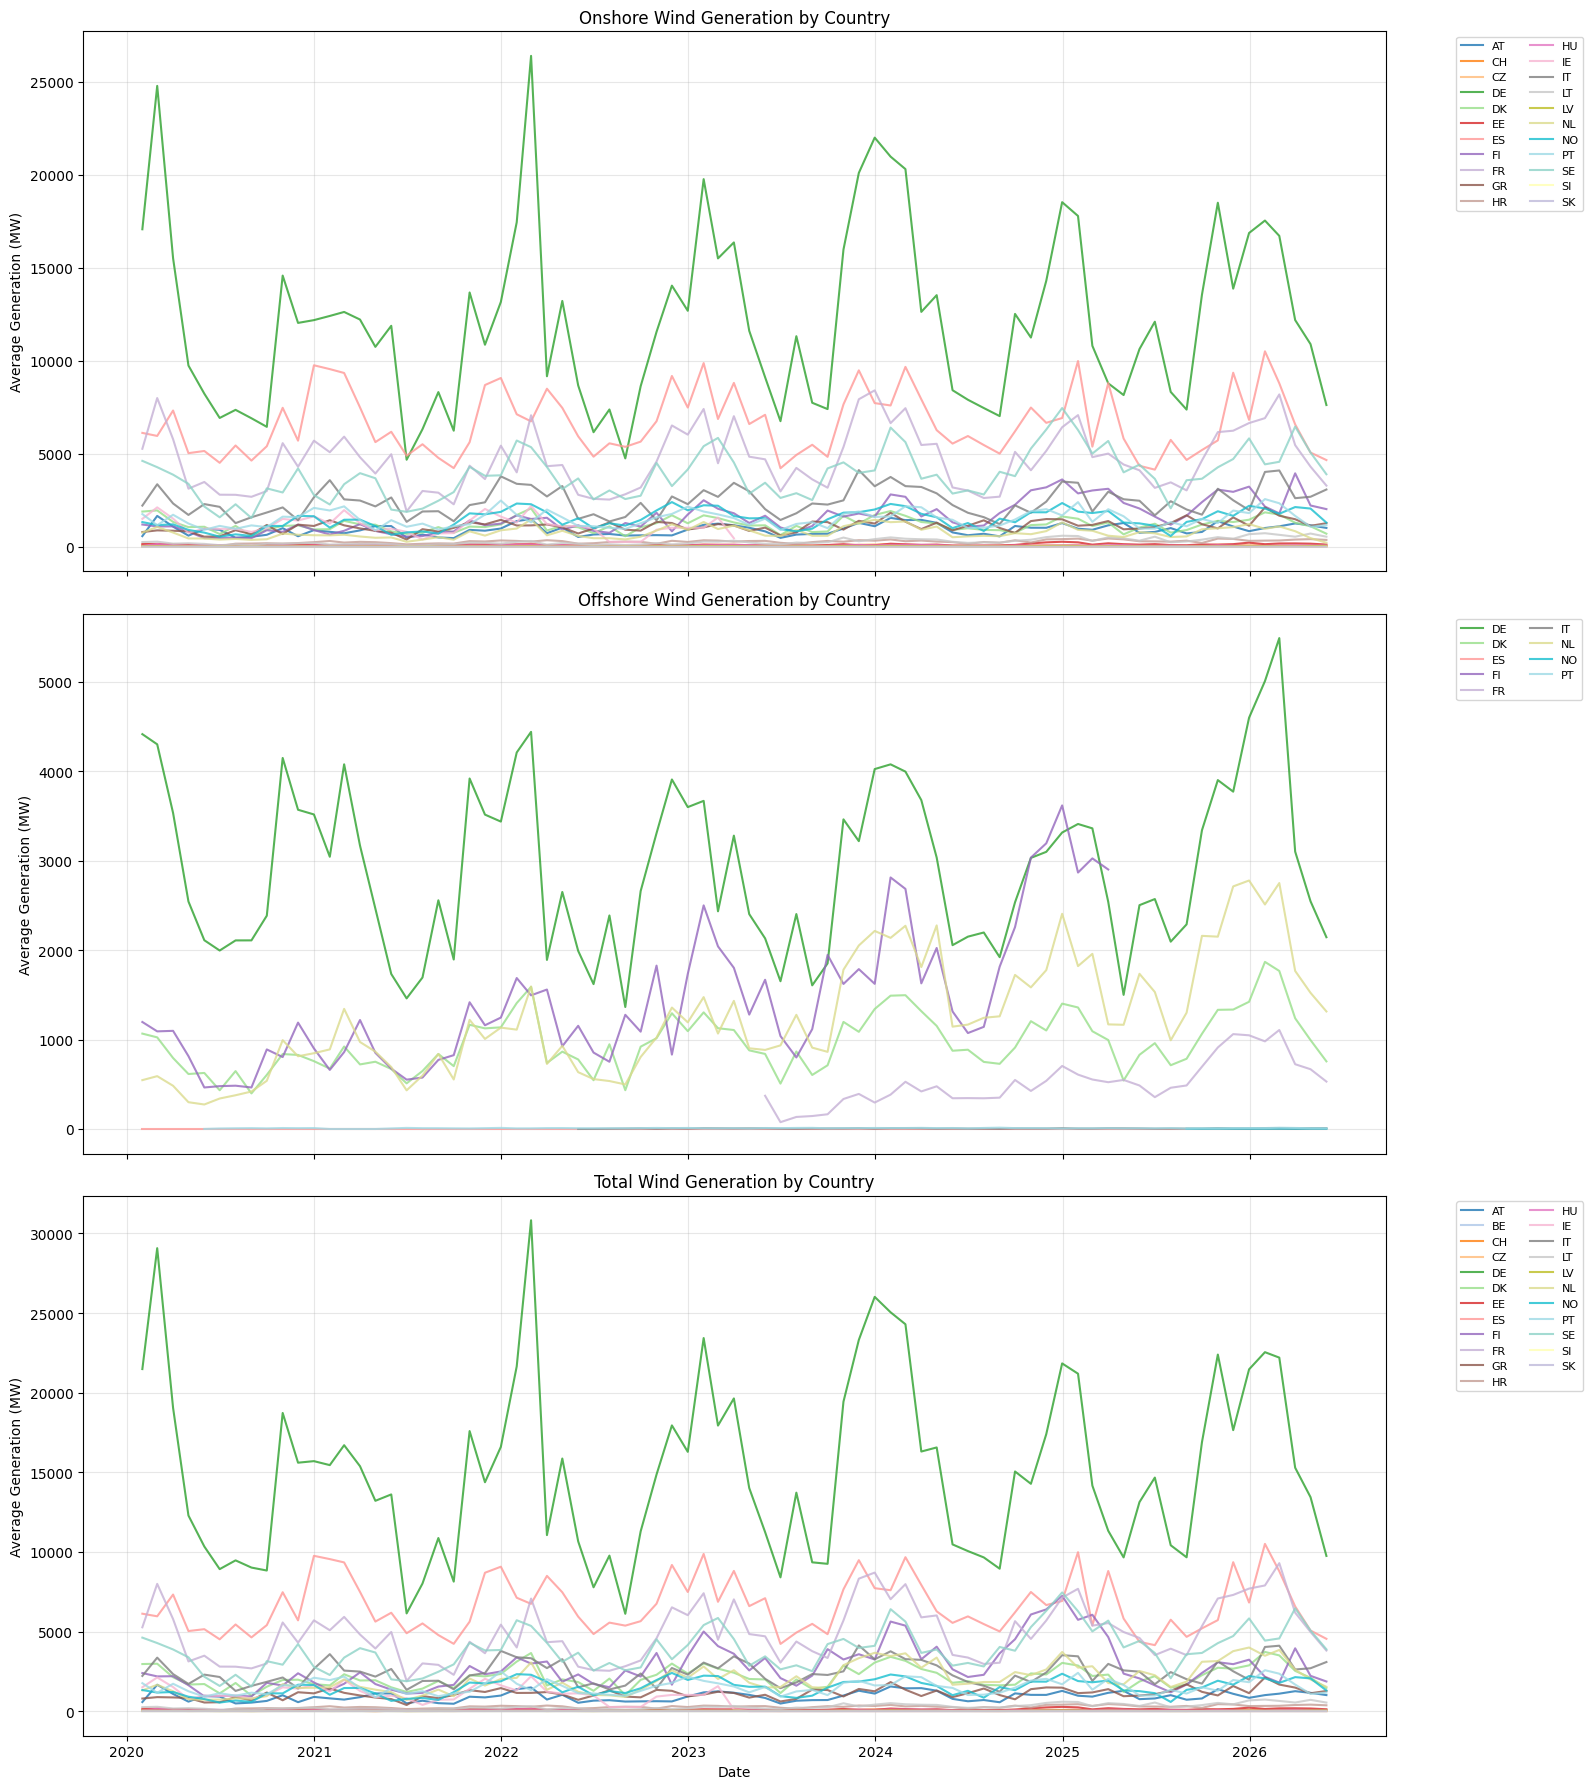

In [101]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# Assign consistent colors to all countries
all_countries = sorted(df_total.columns)
_colors = (plt.cm.tab20.colors[:20] + plt.cm.Set3.colors[:7])
country_colors = {country: _colors[i % len(_colors)] for i, country in enumerate(all_countries)}

# Onshore
monthly_onshore = df_onshore.resample('ME').mean()
for country in sorted(monthly_onshore.columns):
    axes[0].plot(monthly_onshore.index, monthly_onshore[country], label=country, alpha=0.8, color=country_colors[country])
axes[0].set_ylabel('Average Generation (MW)')
axes[0].set_title('Onshore Wind Generation by Country')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
axes[0].grid(True, alpha=0.3)

# Offshore
monthly_offshore = df_offshore.resample('ME').mean()
for country in sorted(monthly_offshore.columns):
    axes[1].plot(monthly_offshore.index, monthly_offshore[country], label=country, alpha=0.8, color=country_colors[country])
axes[1].set_ylabel('Average Generation (MW)')
axes[1].set_title('Offshore Wind Generation by Country')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
axes[1].grid(True, alpha=0.3)

# Total
monthly_total = df_total.resample('ME').mean()
for country in sorted(monthly_total.columns):
    axes[2].plot(monthly_total.index, monthly_total[country], label=country, alpha=0.8, color=country_colors[country])
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Average Generation (MW)')
axes[2].set_title('Total Wind Generation by Country')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison with GO Issuances

We compare ENTSO-E actual wind generation (converted to MWh) with GO issuance data from AIB statistics. The GO data is filtered for electricity certificates with wind as the energy source. Monthly generation is matched to monthly GO issuance by country.

In [102]:
import pandas as pd

path_1 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_1.csv"

df_1 = pd.read_csv(path_1, sep=",")

path_2 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_2.csv"

df_2 = pd.read_csv(path_2, sep=",")

df = pd.concat([df_1, df_2], ignore_index=True)

display(df)

,year_month_date,year,month_name,domain_name,energy_carrier,energy_source_name,energy_source_level1,energy_source_level2,production_technology_name,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025-03-01,2025,March,PT - Portugal,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,1134,0,0,0
1,2026-03-01,2026,March,CZ - Czech Republic,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050500,0,0,0,1918,0,0,1918,0,0,0
2,2025-05-01,2025,May,FR - France,EECS-Electricity,F01010301,Renewable,Renewable - Biomass,T050301,5529,0,0,0,0,0,0,0,0,0
3,2023-03-01,2023,March,CZ - Czech Republic,EECS-Electricity,F01050100,Renewable,Renewable - Wind,T020000,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024-03-01,2024,March,FR - France,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050502,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114135,2022-12-01,2022,December,IT - Italy,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050000,147307,0,128702,0,0,7254,263060,154040,10722,0
114136,2019-05-01,2019,May,NO - Norway,EECS-Electricity,F01050200,Renewable,Renewable - Hydro & Marine,T030000,2309808,40178,8019101,356688,817501,3432797,415589,7062114,984905,0
114137,2020-04-01,2020,April,AT - Austria,EECS-Electricity,F01030300,Renewable,Renewable - Biomass,T050501,0,0,0,357,0,0,0,0,0,0
114138,2022-02-01,2022,February,AT - Austria,EECS-Electricity,F01010300,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,0,0,14626,0


In [103]:
go_df = df.copy()

# Only consider energy carrier electricity for now
go_df = go_df[go_df['energy_carrier'].str.contains('Electricity')]

# Calendar columns
go_df["month"] = go_df["year_month_date"].str.split("-").str[1].astype(int)
go_df["year"] = go_df["year"].astype(int)

go_df = go_df.drop(columns=["year_month_date", "month_name"])

# Classification columns
go_df['country_code'] = go_df['domain_name'].str.split(' ').str[0].astype(str)
go_df['energy_source_category'] = go_df['energy_source_level1'].astype(str)
go_df['energy_source'] = go_df['energy_source_level2'].str.split(' ').str[-1].astype(str)

go_df = go_df.drop(columns=['domain_name',  'energy_carrier', 'energy_source_name', 'energy_source_level1', 'energy_source_level2', 'production_technology_name'])

# Columns reordering
go_df = go_df[['year', 'month', 'country_code', 'energy_source_category', 'energy_source'] + go_df.columns[1:11].tolist()]

# Remove incomplete last month data
go_df = go_df[(go_df['year'] >= 2020) & ~((go_df['year'] == 2026) & (go_df['month'] == 4))]

display(go_df)

,year,month,country_code,energy_source_category,energy_source,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025,3,PT,Renewable,Biomass,0,0,0,0,0,0,1134,0,0,0
1,2026,3,CZ,Renewable,Biomass,0,0,0,1918,0,0,1918,0,0,0
2,2025,5,FR,Renewable,Biomass,5529,0,0,0,0,0,0,0,0,0
3,2023,3,CZ,Renewable,Wind,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024,3,FR,Renewable,Biomass,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114133,2021,11,DK,Renewable,Marine,46596,0,190,0,4673,1024,11840,233,0,0
114135,2022,12,IT,Renewable,Biomass,147307,0,128702,0,0,7254,263060,154040,10722,0
114137,2020,4,AT,Renewable,Biomass,0,0,0,357,0,0,0,0,0,0
114138,2022,2,AT,Renewable,Biomass,0,0,0,0,0,0,0,0,14626,0


In [104]:
# Filter GO data for wind only
wind_go = go_df[go_df['energy_source'] == 'Wind'].copy()

# Monthly GO issuance (MWh) by country
go_issued = wind_go.groupby(['year', 'month', 'country_code'])['production_date_issue'].sum().reset_index()
go_issued.columns = ['year', 'month', 'country_code', 'go_issued_mwh']
go_issued['date'] = pd.to_datetime(go_issued[['year', 'month']].assign(day=1))

# Monthly ENTSO-E generation (MW hourly -> MWh by summing hourly values)
monthly_gen_mwh = df_total.resample('ME').sum()  # sum of hourly MW = MWh

# Reshape to long format for comparison
gen_long = monthly_gen_mwh.reset_index().melt(id_vars='ValueDateUTC', var_name='country_code', value_name='entsoe_mwh')
gen_long['year'] = gen_long['ValueDateUTC'].dt.year
gen_long['month'] = gen_long['ValueDateUTC'].dt.month

# Merge GO issuance with ENTSO-E generation
comparison = gen_long.merge(go_issued, on=['year', 'month', 'country_code'], how='outer')
comparison['date'] = pd.to_datetime(comparison[['year', 'month']].assign(day=1))
comparison = comparison.sort_values(['country_code', 'date'])

# GO issuance rate (% of generation that got GOs issued)
comparison['go_rate'] = (comparison['go_issued_mwh'] / comparison['entsoe_mwh']) * 100

display(comparison[['date', 'country_code', 'entsoe_mwh', 'go_issued_mwh', 'go_rate']].dropna(subset=['entsoe_mwh', 'go_issued_mwh']))

,date,country_code,entsoe_mwh,go_issued_mwh,go_rate
0,2020-01-01,AT,426439.0,422445.0,99.063406
30,2020-02-01,AT,1154772.0,1091789.0,94.545850
60,2020-03-01,AT,805863.0,751064.0,93.199961
89,2020-04-01,AT,431245.0,399271.0,92.585653
118,2020-05-01,AT,719398.0,675568.0,93.907406
...,...,...,...,...,...
2090,2025-11-01,SK,454.3,452.0,99.493727
2120,2025-12-01,SK,266.5,263.0,98.686679
2150,2026-01-01,SK,541.2,534.0,98.669623
2180,2026-02-01,SK,408.3,0.0,0.000000


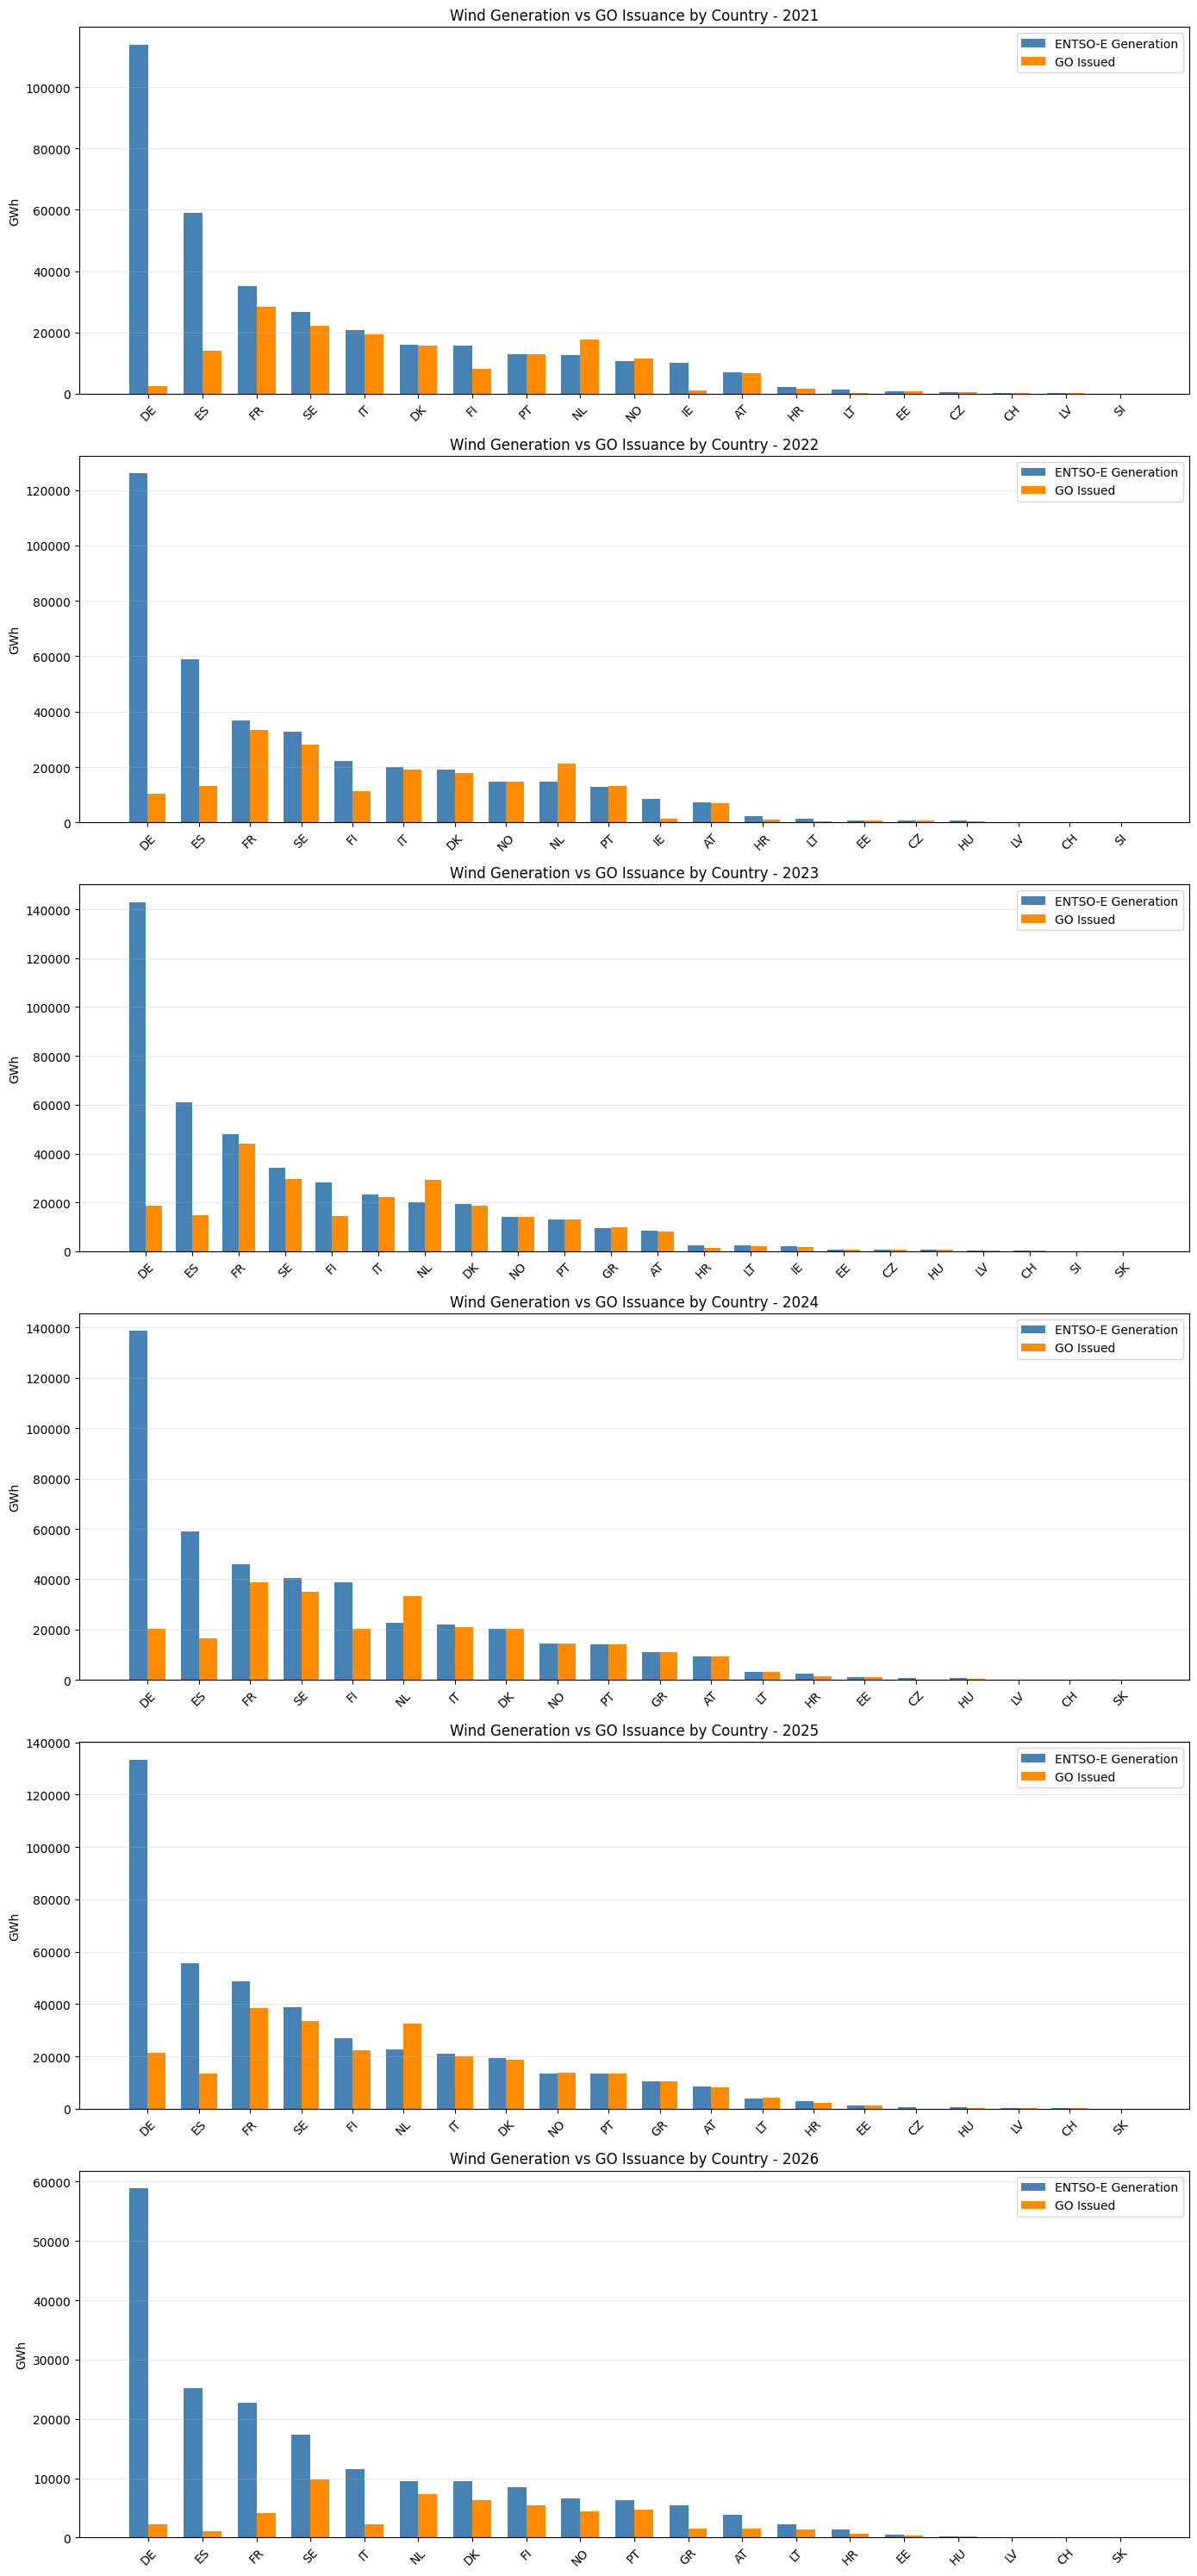

In [105]:
# Plot comparison: annual totals by country
annual = comparison.groupby(['country_code', comparison['date'].dt.year]).agg(
    entsoe_gwh=('entsoe_mwh', lambda x: x.sum() / 1e3),
    go_issued_gwh=('go_issued_mwh', lambda x: x.sum() / 1e3)
).reset_index()
annual.columns = ['country_code', 'year', 'entsoe_gwh', 'go_issued_gwh']

# Filter to countries present in both datasets and year 2021+
annual = annual[(annual['entsoe_gwh'] > 0) & (annual['go_issued_gwh'] > 0) & (annual['year'] >= 2021)]

# Plot per year
years = sorted(annual['year'].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(14, 5 * len(years)))

for i, year in enumerate(years):
    ax = axes[i] if len(years) > 1 else axes
    year_data = annual[annual['year'] == year].sort_values('entsoe_gwh', ascending=False)
    
    x = range(len(year_data))
    width = 0.35
    ax.bar([p - width/2 for p in x], year_data['entsoe_gwh'], width, label='ENTSO-E Generation', color='steelblue')
    ax.bar([p + width/2 for p in x], year_data['go_issued_gwh'], width, label='GO Issued', color='darkorange')
    ax.set_xticks(list(x))
    ax.set_xticklabels(year_data['country_code'], rotation=45)
    ax.set_ylabel('GWh')
    ax.set_title(f'Wind Generation vs GO Issuance by Country - {year}')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [106]:
# Calculate GO factor per country based on 2021-2025 annual totals
historical = annual[(annual['year'] >= 2021) & (annual['year'] <= 2025)].copy()
historical['go_factor'] = historical['go_issued_gwh'] / historical['entsoe_gwh']

# Average factor per country across all available years
go_factors = historical.groupby('country_code').agg(
    avg_factor=('go_factor', 'mean'),
    min_factor=('go_factor', 'min'),
    max_factor=('go_factor', 'max'),
    years_count=('year', 'count'),
    avg_gen_gwh=('entsoe_gwh', 'mean')
).sort_values('avg_gen_gwh', ascending=False).round(3)

print("GO Issuance Factor by Country (2021-2025)")
print("Factor = GO Issued / ENTSO-E Generation")
print("=" * 65)
display(go_factors)

# 2026 data: generation and already-issued GOs
gen_2026 = annual[annual['year'] == 2026][['country_code', 'entsoe_gwh', 'go_issued_gwh']].copy()
gen_2026 = gen_2026.merge(go_factors[['avg_factor']].reset_index(), on='country_code', how='left')

# Estimate expected total 2026 GOs and the not-yet-issued portion
gen_2026['expected_go_gwh'] = gen_2026['entsoe_gwh'] * gen_2026['avg_factor']
gen_2026['not_yet_issued_gwh'] = gen_2026['expected_go_gwh'] - gen_2026['go_issued_gwh']
gen_2026['pct_issued'] = (gen_2026['go_issued_gwh'] / gen_2026['expected_go_gwh'] * 100).round(1)
gen_2026 = gen_2026.sort_values('expected_go_gwh', ascending=False).round(1)

print("\n\n2026 Estimated GO Issuance vs Already Issued (GWh)")
print("Based on generation to date and historical GO factors")
print("=" * 75)
display(gen_2026[['country_code', 'entsoe_gwh', 'avg_factor', 'expected_go_gwh', 'go_issued_gwh', 'not_yet_issued_gwh', 'pct_issued']])

total_expected = gen_2026['expected_go_gwh'].sum()
total_issued = gen_2026['go_issued_gwh'].sum()
print(f"\nTotal across all countries:")
print(f"  Expected 2026 GOs (based on gen to date): {total_expected:,.0f} GWh")
print(f"  Already issued:                           {total_issued:,.0f} GWh")
print(f"  Not yet issued (estimated):               {total_expected - total_issued:,.0f} GWh")
print(f"  Issuance progress:                        {total_issued/total_expected*100:.1f}%")

GO Issuance Factor by Country (2021-2025)
Factor = GO Issued / ENTSO-E Generation


,avg_factor,min_factor,max_factor,years_count,avg_gen_gwh
country_code,,,,,
DE,0.108,0.023,0.159,5,131018.067
ES,0.245,0.226,0.279,5,58690.276
FR,0.853,0.793,0.916,5,42933.349
SE,0.857,0.827,0.869,5,34546.403
FI,0.578,0.513,0.829,5,26367.243
IT,0.949,0.931,0.956,5,21455.060
DK,0.969,0.946,0.995,5,18802.830
NL,1.439,1.409,1.468,5,18559.599
NO,1.020,0.993,1.090,5,13482.769




2026 Estimated GO Issuance vs Already Issued (GWh)
Based on generation to date and historical GO factors


,country_code,entsoe_gwh,avg_factor,expected_go_gwh,go_issued_gwh,not_yet_issued_gwh,pct_issued
7,FR,22705.9,0.9,19368.2,4136.3,15231.8,21.4
17,SE,17272.1,0.9,14802.2,9828.1,4974.1,66.4
14,NL,9509.5,1.4,13684.2,7293.0,6391.2,53.3
11,IT,11597.3,0.9,11005.8,2253.4,8752.4,20.5
3,DK,9431.7,1.0,9139.3,6328.6,2810.6,69.2
15,NO,6616.8,1.0,6749.1,4410.3,2338.8,65.3
2,DE,58890.1,0.1,6360.1,2291.1,4069.0,36.0
16,PT,6256.7,1.0,6269.2,4759.8,1509.4,75.9
5,ES,25126.0,0.2,6155.9,1029.9,5126.0,16.7
8,GR,5409.2,1.0,5506.5,1573.1,3933.5,28.6



Total across all countries:
  Expected 2026 GOs (based on gen to date): 110,962 GWh
  Already issued:                           53,443 GWh
  Not yet issued (estimated):               57,518 GWh
  Issuance progress:                        48.2%


## GO Issuance Factors & 2026 Estimation

Calculate the average ratio of GO issuance to ENTSO-E generation per country (2021–2025), then apply these factors to 2026 generation to estimate expected GO volumes not yet issued.## Conclusion

The comparison between ENTSO-E wind generation and GO issuance across 12 countries reveals significant country-level differences driven by regulatory and structural factors:

**Germany (DE):** Despite being Europe's largest wind power producer, GO issuance is very low. This is due to the *Doppelvermarktungsverbot* (double marketing prohibition) under the EEG — generators receiving feed-in tariffs or market premiums cannot simultaneously obtain GOs. Since the vast majority of German wind capacity was built under EEG support, those installations are excluded from the GO system. Germany is consequently a large net importer of GOs despite its abundant domestic wind generation. This gap is expected to narrow as older turbines exit their 20-year EEG support period and new capacity is increasingly built on a merchant/PPA basis.

**Netherlands (NL):** The only country where GO issuance consistently exceeds measured ENTSO-E generation. This discrepancy arises because ENTSO-E data only captures TSO-visible generation (TenneT NL), while many Dutch onshore wind farms are connected at the distribution level (Liander, Enexis, Stedin). These DSO-connected installations are invisible to ENTSO-E but are fully eligible for GO issuance through VertiCer. The GO data therefore provides a more complete picture of actual Dutch wind generation.

**Nordic countries (NO, SE):** Show a close match between generation and GO issuance, consistent with well-established GO markets and comprehensive TSO reporting.

**Well-covered Western European markets (BE, DK, FR):** Generation and GO issuance align closely. Single-TSO countries with complete national coverage and no EEG-style restrictions. Minor differences are attributable to GO issuance timing (up to 12 months after production) and small DSO-connected capacity.

**Smaller markets (AT, CH, CZ, LT, LV):** Also show a close alignment, as expected in countries with single TSOs providing complete national coverage and without double marketing restrictions.